# How To Draw Curve Fast


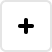
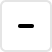
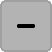
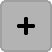
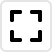
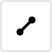
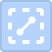

In [1]:
import numpy as np
import pandas as pd

from lets_plot import *
LetsPlot.setup_html()

In [2]:
BG_CLR = '#253494'
EC_CLR = '#ffffcc'

In [3]:
# Curve parametrized equation
def ec_eq(*, a=0, b=0):
    return lambda x, y: y ** 2 - x ** 3 - a * x - b

In [4]:
def level(X, Y, *, eq, c=1):
    level_map = lambda z: np.exp(-c * np.abs(z))
    return level_map(eq(X, Y))

In [5]:
dx, dy = 1.0 / 30.0, 1.0 / 10.0

x = np.arange(-3, 3, dx)
y = np.arange(-3, 3, dy)
X, Y = np.meshgrid(x, y)
curve_eq = ec_eq(a=-1, b=0)
Z = level(X, Y, eq=curve_eq, c=10)

df = pd.DataFrame(dict(x=X.reshape(-1), y=Y.reshape(-1), z=Z.reshape(-1)))

In [6]:
bg_layer = geom_rect(xmin=df.x.min(), xmax=df.x.max(), \
                     ymin=df.y.min(), ymax=df.y.max(), fill=BG_CLR)
clr_layer = scale_color_gradient(low=BG_CLR, high=EC_CLR)
fill_layer = scale_fill_gradient(low=BG_CLR, high=EC_CLR)
size_layer = ggsize(600, 450)

In [7]:
ggplot() + \
    bg_layer + \
    geom_point(aes(x='x', y='y', color='z'), data=df[df.z > 0.5].sort_values(by='z')) + \
    clr_layer + coord_fixed() + size_layer + \
    ggtitle('Elliptic Curve by Points')

In [8]:
ggplot() + \
    geom_bin2d(aes(x='x', y='y', fill='z'), data=df, stat='identity', color=BG_CLR) + \
    fill_layer + size_layer + \
    ggtitle('Elliptic Curve by 2D-Bins')

In [9]:
ggplot() + \
    geom_tile(aes(x='x', y='y', fill='z'), data=df, color=BG_CLR) + \
    fill_layer + size_layer + \
    ggtitle('Elliptic Curve by Tiles')

In [10]:
ggplot() + \
    geom_raster(aes(x='x', y='y', fill='z'), data=df) + \
    fill_layer + size_layer + \
    ggtitle('Elliptic Curve by Raster')

In [11]:
ggplot() + \
    bg_layer + \
    geom_contour(aes(x='x', y='y', z='z', color='..level..'), data=df, bins=4) + \
    clr_layer + size_layer + \
    ggtitle('Elliptic Curve by Contours')

In [12]:
ggplot() + \
    geom_contourf(aes(x='x', y='y', z='z', fill='..level..'), data=df, binwidth=.3) + \
    fill_layer + size_layer + \
    ggtitle('Elliptic Curve by Filled Contours')